In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import loguniform, uniform
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import mlflow
import mlflow.sklearn

# Параметры для генерации даннных
STUDENT_ID = 796695 
CURRENT_YEAR = 2026
RANDOM_SEED = STUDENT_ID + CURRENT_YEAR

print(f"Seed для генерации: {RANDOM_SEED}")

Seed для генерации: 798721


### 2. Генерация синтетического датасета
Мы генерируем датасет со следующими параметрами:
*   Количество объектов: 400.
*   Количество признаков: 5 (из них 3 информативных и 2 шумовых).
*   Количество классов: 3.

Дополнительно, согласно заданию, мы вручную изменяем средние значения (`shifts`) и масштабы (`scales`) признаков так, чтобы они отличались друг от друга более чем на 50%. Полученные данные сохраняются в CSV-файл.

In [2]:
# Генерируем 400 объектов, 5 признаков (3 информативных, 2 лишних)
X_raw, y_raw = make_classification(
    n_samples=400, 
    n_features=5, 
    n_informative=3, 
    n_redundant=2, 
    n_classes=3, 
    random_state=RANDOM_SEED
)

# Создаем разный масштаб и разные средние (отличия > 50%)
# Признак 1: масштаб 10, среднее -20
# Признак 2: масштаб 1, среднее 50 и так далее
shifts = np.array([-20, 50, 0, 10, -5])
scales = np.array([10.0, 1.0, 5.0, 0.5, 2.5])

X_final = (X_raw + shifts) * scales

# Формируем Датафрейм
columns = [f'feature_{i+1}' for i in range(5)]
df_init = pd.DataFrame(X_final, columns=columns)
df_init['target'] = y_raw

# Сохраняем в файл CSV
df_init.to_csv('dataset.csv', index=False)
print("Файл 'dataset.csv' создан.")

Файл 'dataset.csv' создан.


### 3. Загрузка данных и статистическое описание
Загружаем ранее созданный файл `dataset.csv`. Для первичного анализа распределения признаков используем **7-point summary** (функция `describe`), которая включает в себя: среднее, стандартное отклонение, минимум, максимум и квартили (25%, 50%, 75%).

In [3]:
data = pd.read_csv('dataset.csv')

print("7-point summary (описание распределений):")
data.describe()

7-point summary (описание распределений):


,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-199.738863,49.629362,-0.306546,4.865224,-11.517067,0.995000
std,12.718133,1.458380,6.613386,0.597900,4.815123,0.816481
min,-227.976876,45.801116,-15.754379,3.756726,-23.975554,0.000000
25%,-209.849992,48.596142,-5.453213,4.380618,-15.373633,0.000000
50%,-199.855625,49.508111,-0.434894,4.820996,-11.402472,1.000000
75%,-189.743086,50.512422,5.019431,5.231668,-8.296086,2.000000
max,-155.717072,54.108272,19.659300,6.860888,2.226752,2.000000


### 4. Корреляционный анализ
Оценим взаимосвязь признаков с помощью коэффициента корреляции Пирсона. Это позволит нам визуально определить, какие признаки имеют наибольшее влияние на целевую переменную (`target`), а какие являются малозначимыми (шумовыми).

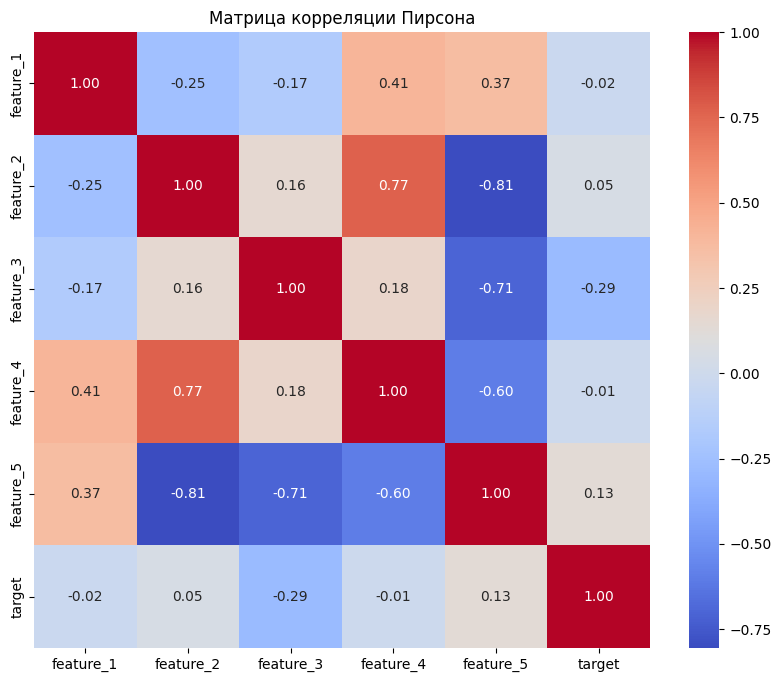

Корреляция с целевой переменной:
target       1.000000
feature_5    0.132477
feature_2    0.048743
feature_4   -0.014399
feature_1   -0.023850
feature_3   -0.290289
Name: target, dtype: float64


In [4]:
# Оценка влияния признаков на целевую переменную
corr_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Матрица корреляции Пирсона")
plt.show()

print("Корреляция с целевой переменной:")
print(corr_matrix['target'].sort_values(ascending=False))

### 5. Анализ баланса классов
Для качественного обучения модели классификации важно знать, сбалансированы ли классы. Существенный перекос в сторону одного из классов может привести к смещению предсказаний модели.

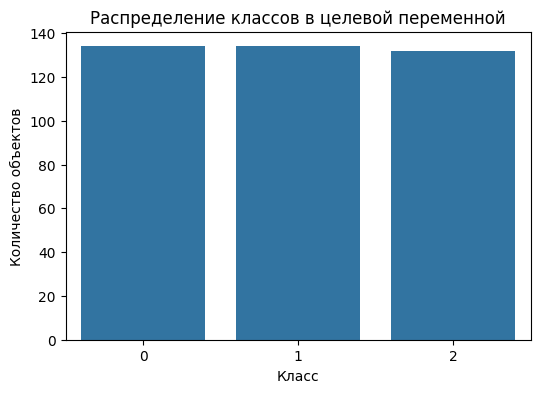

target
1    0.335
0    0.335
2    0.330
Name: proportion, dtype: float64


In [5]:
# Проверка сбалансированности выборки
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='target')
plt.title("Распределение классов в целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

# Вывод долей классов
print(data['target'].value_counts(normalize=True))

### 6. Подготовка данных к обучению
Разделяем данные на матрицу объект-признак (`X`) и вектор целевых значений (`y`). Осуществляем разбиение выборки на обучающую и тестовую в соотношении 80/20 с применением стратификации по целевой переменной.

In [6]:
# Разделение на признаки и таргет
X = data.drop('target', axis=1)
y = data['target']

# Разбиение на обучающую и тестовую (20%) выборки со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (320, 5)
Размер тестовой выборки: (80, 5)


### 7. Построение модели: Логистическая регрессия
Первая модель — логистическая регрессия с регуляризацией. Мы используем `RandomizedSearchCV` для поиска оптимальных параметров: силы регуляризации (`C`) и типа штрафа (`penalty`). 

*Примечание:* Использование алгоритма `saga` обусловлено его эффективностью на больших выборках и поддержкой всех типов регуляризации.

**Параметры:**
* **`C`** — обратная сила регуляризации. Чем *меньше* значение, тем *сильнее* штраф за сложность модели (защита от переобучения).
* **`L1` (Lasso)** — может обнулять веса неважных признаков, работая как встроенный фильтр (отбор признаков).
* **`L2` (Ridge)** — плавно уменьшает веса всех признаков, не давая ни одному из них перетянуть влияние на себя. Хорошо работает при корреляции признаков.
* **`ElasticNet`** — комбинация L1 и L2: одновременно отбирает признаки и сохраняет стабильность модели.

In [7]:
# Инициализация модели
lr_model = LogisticRegression(solver='saga', max_iter=5000)

# Пространство гиперпараметров
lr_params = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'l1_ratio': uniform(0, 1),
    'class_weight': [None, 'balanced']
}

# Случайный поиск по сетке
lr_search = RandomizedSearchCV(
    lr_model, 
    param_distributions=lr_params, 
    n_iter=100, 
    cv=5, 
    scoring='accuracy', 
    random_state=RANDOM_SEED, 
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print(f"Лучшие параметры LogReg: {lr_search.best_params_}")
print(f"Accuracy на кросс-валидации: {lr_search.best_score_:.4f}")

Лучшие параметры LogReg: {'C': np.float64(0.02477320451109351), 'class_weight': 'balanced', 'l1_ratio': np.float64(0.277264114628223), 'penalty': 'elasticnet'}
Accuracy на кросс-валидации: 0.6875


d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
# MLflow отчет для RandomizedSearchCV (LogReg)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="LogReg_RandomSearch"):
    mlflow.log_params({
        "model_type": "LogisticRegression",
        "search_type": "RandomizedSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", lr_search.best_score_)

    for param_name, param_value in lr_search.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(lr_search.best_estimator_, artifact_path="model")

### 8. Оценка качества логистической регрессии
Проверим качество модели на тестовых данных, которые она не видела при обучении. Основными метриками будут являться Precision, Recall и F1-score для каждого из трех классов.

In [8]:
# Валидация на тестовых данных
lr_predictions = lr_search.predict(X_test)

print("Отчет по классификации (Logistic Regression) на тесте:")
print(classification_report(y_test, lr_predictions))

Отчет по классификации (Logistic Regression) на тесте:
              precision    recall  f1-score   support

           0       0.58      0.41      0.48        27
           1       0.76      0.81      0.79        27
           2       0.56      0.69      0.62        26

    accuracy                           0.64        80
   macro avg       0.63      0.64      0.63        80
weighted avg       0.63      0.64      0.63        80



### 8-1. Плюсы и минусы логистической регрессии

### Плюсы

1. Понятная интерпретация влияния признаков на результат.
2. Выдает вероятность события, а не класс.
3. Быстро обучается и работает на данных.
4. Простая реализация и низкие системные требования.

### Минусы

1. Не находит сложные нелинейные зависимости данных.
2. Чувствительна к сильной корреляции между признаками.
3. Аномальные выбросы сильно снижают точность прогноза.
4. Требует тщательной предварительной подготовки всех признаков.

### 9. Построение модели: Метод k-ближайших соседей (k-NN)
Вторая модель — k-NN. Этот метод основан на измерении расстояния между объектами. С помощью `GridSearchCV` мы найдем наилучшее количество соседей и оптимальную метрику расстояния (Евклидова, Манхэттенская и др.).

In [9]:
# Инициализация модели k-NN
knn_model = KNeighborsClassifier()

# Поиск по сетке (GridSearch)
knn_params = {
    'n_neighbors': range(1, 31, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(
    knn_model, 
    param_grid=knn_params, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print(f"Лучшие параметры k-NN: {knn_grid.best_params_}")
print(f"Accuracy на кросс-валидации: {knn_grid.best_score_:.4f}")

Лучшие параметры k-NN: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Accuracy на кросс-валидации: 0.8063


In [ ]:
# MLflow отчет для GridSearchCV (k-NN)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="KNN_GridSearch"):
    mlflow.log_params({
        "model_type": "KNeighborsClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", knn_grid.best_score_)

    for param_name, param_value in knn_grid.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(knn_grid.best_estimator_, artifact_path="model")

### 10. Оценка качества k-NN и общие выводы
Проводим финальную оценку k-NN. 

**Важное замечание по масштабированию:** 
В ходе анализа (этап 3) было выявлено, что признаки имеют существенно разный масштаб. Поскольку k-NN крайне чувствителен к расстояниям, в реальных задачах здесь рекомендуется применять `StandardScaler`. Однако, в рамках текущего исследования, параметры подбирались на исходных данных для оценки устойчивости алгоритмов к разным масштабам «из коробки».

In [10]:
# Валидация на тестовых данных
best_knn = knn_grid.best_estimator_
knn_predictions = best_knn.predict(X_test)

print("Отчет по классификации (k-NN) на тесте:")
print(classification_report(y_test, knn_predictions))

Отчет по классификации (k-NN) на тесте:
              precision    recall  f1-score   support

           0       0.73      0.89      0.80        27
           1       0.78      0.67      0.72        27
           2       0.88      0.81      0.84        26

    accuracy                           0.79        80
   macro avg       0.79      0.79      0.79        80
weighted avg       0.79      0.79      0.79        80



### 11. Метод SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm = SVC(kernel='rbf', C = 0.001)

# C - связь с зазором между классами
# kernel - тип ядра ('linear', 'rbf', 'poly', 'sigmoid') определяет как преобразовывать данные в пространство более высокой размерности
# gamma - влияет на кривизну разделающей линии; малые значения - гладкие, большие - сложные

svm.fit(X_train, y_train)


print("Train")
y_train_pred = svm.predict( X_train )
print( classification_report( y_train, y_train_pred, digits=4 ) )

print()
print("Test")
y_test_pred = svm.predict( X_test )
print( classification_report( y_test, y_test_pred, digits=4 ) )

Train
              precision    recall  f1-score   support

           0     0.3035    0.5701    0.3961       107
           1     0.6050    0.6729    0.6372       107
           2     0.0000    0.0000    0.0000       106

    accuracy                         0.4156       320
   macro avg     0.3028    0.4143    0.3444       320
weighted avg     0.3038    0.4156    0.3455       320


Test
              precision    recall  f1-score   support

           0     0.3214    0.6667    0.4337        27
           1     0.6250    0.5556    0.5882        27
           2     0.0000    0.0000    0.0000        26

    accuracy                         0.4125        80
   macro avg     0.3155    0.4074    0.3407        80
weighted avg     0.3194    0.4125    0.3449        80



d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Прога\ML\ML_2026\.venv

In [12]:
from sklearn.model_selection import cross_val_score

ac = cross_val_score(svm, X, y, scoring ='accuracy')
ac.mean()

np.float64(0.38500000000000006)

In [16]:
from sklearn.model_selection import GridSearchCV

svm_gs = GridSearchCV( 
    estimator = svm,                                                  # модель
    param_grid = {  "kernel": ["linear", "poly", "rbf", "sigmoid"],   # 4
                    'C':       [ 10**i for i in range(-5,6)]           # 11
                },
    scoring = 'accuracy',                                 # метрика
    cv = None,                                            # кол-во частей для крос-валидации
    n_jobs = -1,                                          # подбирать паралельно с использованием оптимального числа
    verbose = 2
    )


svm_gs.fit( X_train, y_train)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(C=0.001)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.0001, ...], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [ ]:
# MLflow отчет для GridSearchCV (SVM)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="SVM_GridSearch"):
    mlflow.log_params({
        "model_type": "SVC",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", svm_gs.best_score_)

    for param_name, param_value in svm_gs.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(svm_gs.best_estimator_, artifact_path="model")

In [14]:
svm_gs.best_params_

{'C': 50, 'kernel': 'rbf'}

In [15]:
svm_gs.cv_results_['mean_test_score']

array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
       0.659375, 0.6375  , 0.603125, 0.41875 , 0.6625  , 0.65    ,
       0.63125 , 0.446875, 0.653125, 0.653125, 0.64375 , 0.39375 ,
       0.665625, 0.6625  , 0.653125, 0.390625, 0.66875 , 0.665625,
       0.671875, 0.39375 ])

In [17]:
y_test_pred = svm_gs.predict( X_test )
print( classification_report( y_test, y_test_pred, digits=4 ) )

              precision    recall  f1-score   support

           0     0.8000    0.8889    0.8421        27
           1     0.8148    0.8148    0.8148        27
           2     0.9130    0.8077    0.8571        26

    accuracy                         0.8375        80
   macro avg     0.8426    0.8371    0.8380        80
weighted avg     0.8417    0.8375    0.8378        80



In [18]:
y_train_pred = svm_gs.predict( X_train )
print( classification_report( y_train, y_train_pred, digits=4 ) )

              precision    recall  f1-score   support

           0     0.8316    0.7383    0.7822       107
           1     0.7417    0.8318    0.7841       107
           2     0.8952    0.8868    0.8910       106

    accuracy                         0.8187       320
   macro avg     0.8228    0.8190    0.8191       320
weighted avg     0.8226    0.8187    0.8189       320



### 12. Обучение модели: дерево решений (Decision Tree)
Добавим модель дерева решений и подберем гиперпараметры с помощью `GridSearchCV`. 

**Что подбираем:**
* **`criterion`** - функция качества разбиения (`gini` или `entropy`).
* **`max_depth`** - максимальная глубина дерева (контроль переобучения).
* **`min_samples_split`** - минимальное число объектов для разбиения узла.
* **`min_samples_leaf`** - минимальное число объектов в листе.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Инициализация модели дерева решений
tree_model = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Поиск по сетке (GridSearch)
tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

tree_grid = GridSearchCV(
    tree_model,
    param_grid=tree_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print(f"Лучшие параметры Decision Tree: {tree_grid.best_params_}")
print(f"Accuracy на кросс-валидации: {tree_grid.best_score_:.4f}")

In [ ]:
# MLflow отчет для GridSearchCV (Decision Tree)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="DecisionTree_GridSearch"):
    mlflow.log_params({
        "model_type": "DecisionTreeClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_metric("best_cv_score", tree_grid.best_score_)

    for param_name, param_value in tree_grid.best_params_.items():
        mlflow.log_param(f"best_{param_name}", param_value)

    mlflow.sklearn.log_model(tree_grid.best_estimator_, artifact_path="model")

### 13. Оценка качества дерева решений
Проверим качество лучшей версии дерева решений на тестовой выборке.

In [ ]:
# Проверка на тестовой выборке
best_tree = tree_grid.best_estimator_
tree_predictions = best_tree.predict(X_test)

print("Отчет по классификации (Decision Tree) на тесте:")
print(classification_report(y_test, tree_predictions))

## Обучение

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Базовая модель дерева решений
tree = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=RANDOM_SEED)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy train (Decision Tree): {acc_train:.4f}")
print(f"Accuracy test (Decision Tree): {acc_test:.4f}")
print("\nОтчет на тестовой выборке:")
print(classification_report(y_test, y_pred_test))

##Поиск гиперпараметров

In [ ]:
from sklearn.model_selection import GridSearchCV

param_dist = {
    'max_depth': [3, 5, 7, 9, 11, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

tree_gs = GridSearchCV(
    estimator=tree,
    param_grid=param_dist,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

tree_gs.fit(X_train, y_train)

y_pred_train = tree_gs.predict(X_train)
y_pred_test = tree_gs.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

with mlflow.start_run(run_name="DecisionTreeClassifier_normal"):
    mlflow.log_params({
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1],
        "scaling": "Normalization"
    })

    mlflow.log_param("model_type", "decision_tree")
    mlflow.log_param("grid_search_params", str(param_dist))

    mlflow.log_metrics({
        "acc_train": acc_train,
        "acc_test": acc_test,
        "best_cv_score": tree_gs.best_score_
    })

    mlflow.sklearn.log_model(tree_gs.best_estimator_, artifact_path="model")

In [ ]:
mlflow.search_runs()

In [ ]:
tree.get_depth()

In [ ]:
tree.get_params()

In [ ]:
tree_gs.best_params_

# Беггинг

## Обучение

In [ ]:
from sklearn.ensemble import BaggingClassifier

base_tree = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=RANDOM_SEED)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=150,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

bagging_model.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, bagging_model.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, bagging_model.predict(X_test), digits=4))

## Поиск по сетке гиперпараметров

In [ ]:
bagging_grid_params = {
    'n_estimators': [50, 100, 150],
    'max_samples': [0.7, 0.8, 1.0],
    'estimator__max_depth': [3, 5, 7],
    'estimator__criterion': ['gini', 'entropy']
}

bagging_search = GridSearchCV(
    estimator=BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_SEED),
        random_state=RANDOM_SEED
    ),
    param_grid=bagging_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

bagging_search.fit(X_train, y_train)

bagging_train_pred = bagging_search.predict(X_train)
bagging_test_pred = bagging_search.predict(X_test)

bagging_acc_train = accuracy_score(y_train, bagging_train_pred)
bagging_acc_test = accuracy_score(y_test, bagging_test_pred)

print(f"Лучшие параметры Bagging: {bagging_search.best_params_}")
print(f"Best CV accuracy: {bagging_search.best_score_:.4f}")
print(f"Train accuracy: {bagging_acc_train:.4f}")
print(f"Test accuracy: {bagging_acc_test:.4f}")

In [ ]:
# MLflow отчет для GridSearchCV (Bagging)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="Bagging_GridSearch"):
    mlflow.log_params({
        "model_type": "BaggingClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(bagging_grid_params))
    mlflow.log_metrics({
        "acc_train": bagging_acc_train,
        "acc_test": bagging_acc_test,
        "best_cv_score": bagging_search.best_score_
    })

    mlflow.sklearn.log_model(bagging_search.best_estimator_, artifact_path="model")

# Случайный лес

## Обучение

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

forest.fit(X_train, y_train)

print("Train")
print(classification_report(y_train, forest.predict(X_train), digits=4))
print("\nTest")
print(classification_report(y_test, forest.predict(X_test), digits=4))

## Поиск по сетке гиперпараметров

In [ ]:
rf_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED),
    param_grid=rf_grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_train_pred = rf_search.predict(X_train)
rf_test_pred = rf_search.predict(X_test)

rf_acc_train = accuracy_score(y_train, rf_train_pred)
rf_acc_test = accuracy_score(y_test, rf_test_pred)

print(f"Лучшие параметры RandomForest: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")
print(f"Train accuracy: {rf_acc_train:.4f}")
print(f"Test accuracy: {rf_acc_test:.4f}")

In [ ]:
# MLflow отчет для GridSearchCV (Random Forest)
mlflow.set_experiment("ML_2026_Search_Reports")

with mlflow.start_run(run_name="RandomForest_GridSearch"):
    mlflow.log_params({
        "model_type": "RandomForestClassifier",
        "search_type": "GridSearchCV",
        "train_size": len(y_train),
        "test_size": len(y_test),
        "features_n": X_train.shape[1]
    })

    mlflow.log_param("grid_search_params", str(rf_grid_params))
    mlflow.log_metrics({
        "acc_train": rf_acc_train,
        "acc_test": rf_acc_test,
        "best_cv_score": rf_search.best_score_
    })

    mlflow.sklearn.log_model(rf_search.best_estimator_, artifact_path="model")